# exp04_xgb_cuantilico — XGBoost cuantílico (P10/P50/P90)

Pronóstico **probabilístico**: en días nublados/variables un punto siempre falla
(kt de alta varianza), así que se predice una **banda de incertidumbre**. El P50 es
el punto (debe seguir batiendo a persistence); [P10,P90] es la banda.

Métricas de intervalo: **pinball** (proper score), **cobertura** (objetivo 0.80 para
P10-P90) y **anchura** (más estrecha = mejor, sin perder cobertura). Reproducir:
`python -m forecasting.experiments.run exp04_xgb_cuantilico`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import matplotlib.pyplot as plt
from forecasting.experiments.reporte import ReporteExperimento

r = ReporteExperimento.de('exp04_xgb_cuantilico', ejecutar=False)
r.resumen()

exp04_xgb_cuantilico v1 | feature-set base-nocturno (45 feats) | best_iter 286
Test global: RMSE 80.28 vs persist 84.87 | skill 0.0541 | R² 0.925


## Métricas puntuales (P50) globales — debe batir a persistence

In [2]:
r.metrics_global.round(3)

,segmento,n,RMSE_persistence,RMSE_modelo,MAE_modelo,MBE_modelo,R2_persistence,R2_modelo,skill,split
0,global,4112,84.625,79.062,39.728,8.191,0.921,0.931,0.066,val
1,limpio_ff0,3712,86.679,80.965,40.189,7.860,0.912,0.923,0.066,val
2,rellenado_ff_pos,400,62.425,58.519,35.444,11.260,0.890,0.903,0.063,val
3,global,4123,84.873,80.281,43.383,7.976,0.916,0.925,0.054,test
4,limpio_ff0,3734,86.482,82.046,44.477,8.409,0.906,0.915,0.051,test
5,rellenado_ff_pos,389,67.497,60.789,32.880,3.824,0.887,0.908,0.099,test


## Métricas de intervalo (P10-P90)

**Hallazgo v1:** la banda se **ensancha correctamente** en nublado/variable (buena
señal), pero queda **infracubierta** (~0.50 vs 0.80) por el borde kt=1 en cielo
despejado (el P90 suave no alcanza el pico kt=1). Siguiente: recalibración conformal (v2).

In [3]:
display(r.intervalo.round(3))
display(r.intervalo_regimen.round(3))

,n,pinball_medio,cobertura_80,cobertura_nominal,anchura_media
0,4123,14.361,0.504,0.8,131.522


,regimen_nubosidad,n,cobertura,anchura_media
0,cubierto (kt<0.3),286,0.430,199.441
1,parcial (0.3-0.7),708,0.716,202.464
2,despejado (kt>=0.7),3129,0.463,109.262


## Banda de incertidumbre en el tiempo (observado vs P50 vs P10-P90)

La banda se corta en la noche. Compara un tramo variable con uno despejado.

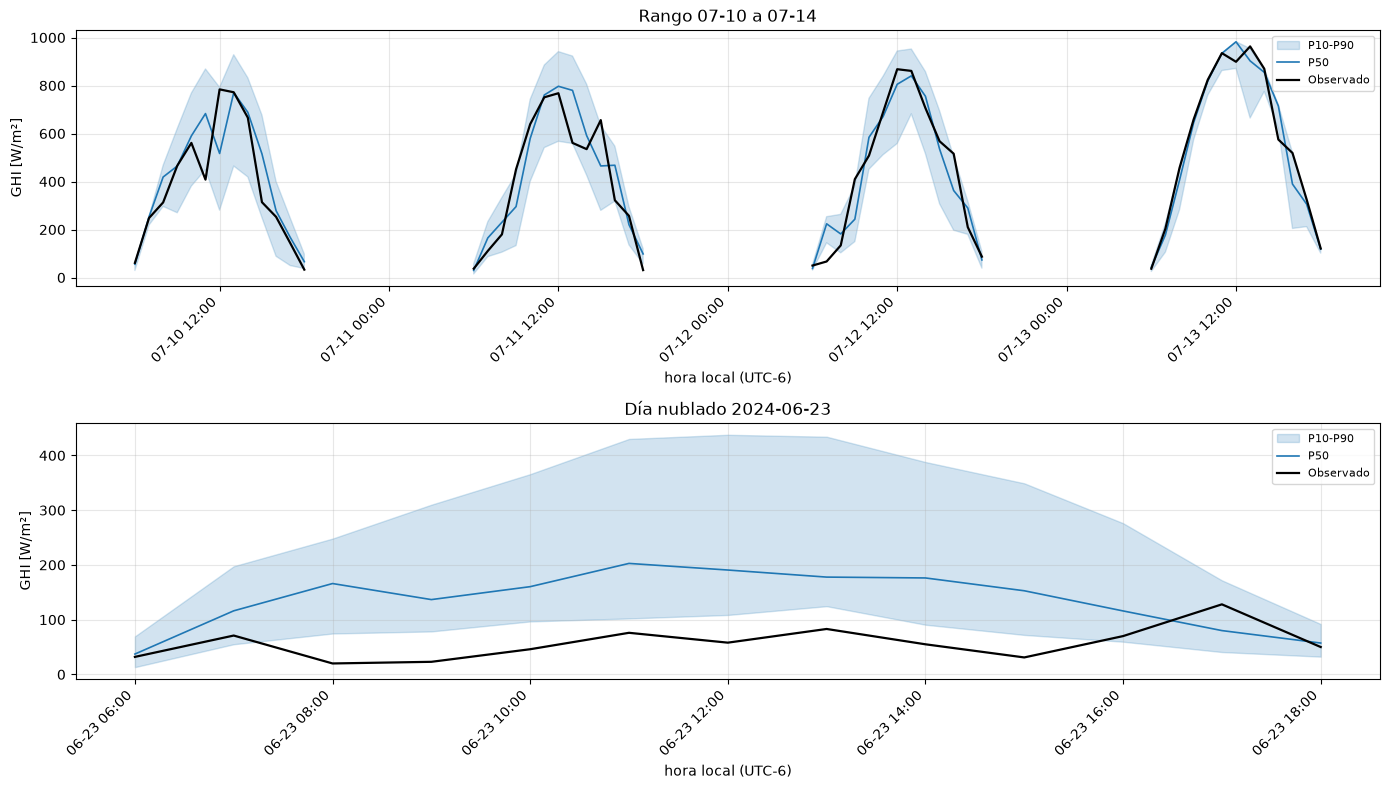

In [4]:
viz = r.visualizador()
fig, ax = plt.subplots(2, 1, figsize=(14, 8))
viz.serie_intervalo(inicio='2024-07-10', fin='2024-07-14', ax=ax[0]); ax[0].set_title('Rango 07-10 a 07-14')
# Un día nublado (banda ancha) tomado del ranking de días difíciles.
dia = viz.dias_dificiles(n=1, criterio='nublado').index[0].strftime('%Y-%m-%d')
viz.serie_intervalo(dia=dia, ax=ax[1]); ax[1].set_title(f'Día nublado {dia}')
plt.tight_layout(); plt.show()

## Métricas puntuales por régimen (test)

In [5]:
display(r.regimen_nubosidad.round(3))
display(r.regimen_rampa.round(3))

,regimen_nubosidad,n,RMSE_modelo,RMSE_persistence,MAE_modelo,R2_modelo,skill
0,cubierto (kt<0.3),286,142.679,135.642,98.990,-3.673,-0.052
1,parcial (0.3-0.7),708,120.925,127.541,82.800,0.481,0.052
2,despejado (kt>=0.7),3129,57.646,64.260,29.381,0.956,0.103


,regimen_rampa,n,RMSE_modelo,RMSE_persistence,MAE_modelo,R2_modelo,skill
0,rampa suave (<0.1),2818,32.333,23.286,18.160,0.987,-0.389
1,rampa moderada (0.1-0.25),817,93.304,97.163,73.479,0.864,0.040
2,rampa fuerte (>0.25),487,184.144,204.961,138.869,0.307,0.102


## Series temporales del P50 vs persistence y dispersión

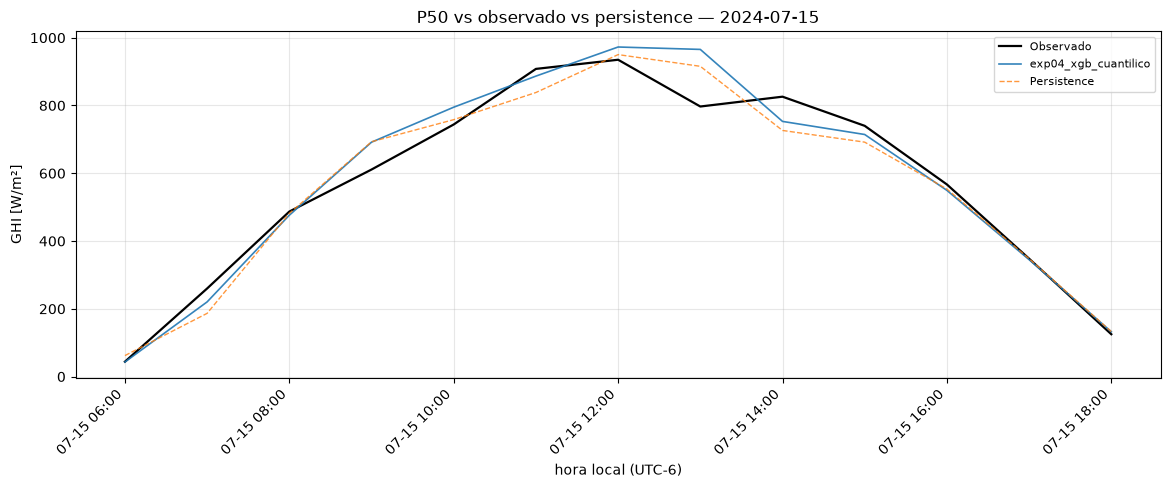

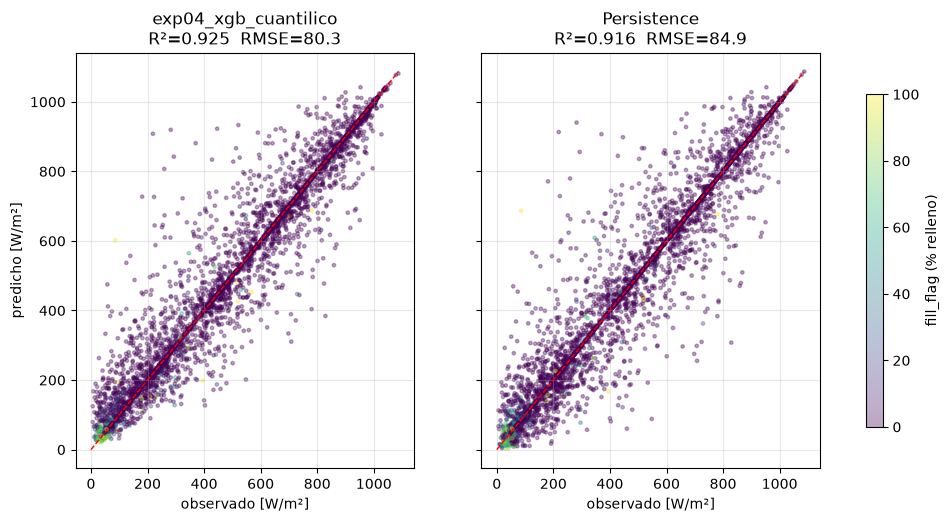

In [6]:
viz.serie_temporal(dia='2024-07-15'); plt.title('P50 vs observado vs persistence — 2024-07-15'); plt.show()
viz.dispersion(); plt.show()